# LSTM Forecasting

Capstone Project - Time Series Analysis 2026

## 0. Imports & Config

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

os.makedirs('../outputs/forecasts', exist_ok=True)
os.makedirs('../outputs/plots',     exist_ok=True)

print('Imports OK.')

I0000 00:00:1778618244.561577   17534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778618244.570278   17534 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778618248.006378   17534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778618248.009792   17534 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Imports OK.


In [2]:
TICKERS = {
    'Banking' : 'HDFCBANK.NS',
    'IT'      : 'INFY.NS',
    'Pharma'  : 'SUNPHARMA.NS',
    'FMCG'    : 'HINDUNILVR.NS'
}

TICKER_LIST      = list(TICKERS.values())
SECTOR_MAP       = {v: k for k, v in TICKERS.items()}
FORECAST_HORIZON = 2
LSTM_WINDOW      = 30
EPOCHS           = 50
BATCH_SIZE       = 32

---
## 1. Load Processed Data & Scalers

In [3]:
train_close = pd.read_csv('../data/processed/train_close.csv', index_col=0, parse_dates=True)
test_close  = pd.read_csv('../data/processed/test_close.csv',  index_col=0, parse_dates=True)
scaled_train = pd.read_csv('../data/processed/scaled_train.csv', index_col=0, parse_dates=True)
scaled_test  = pd.read_csv('../data/processed/scaled_test.csv',  index_col=0, parse_dates=True)

with open('../data/processed/scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

print(f'Train: {train_close.index[0].date()} → {train_close.index[-1].date()}  ({len(train_close)} rows)')
print(f'Test : {test_close.index[0].date()}  → {test_close.index[-1].date()}  ({len(test_close)} rows)')
print(f'Scalers loaded: {list(scalers.keys())}')

Train: 2021-01-01 → 2025-06-30  (1110 rows)
Test : 2025-07-01  → 2025-12-30  (125 rows)
Scalers loaded: ['HDFCBANK.NS', 'INFY.NS', 'SUNPHARMA.NS', 'HINDUNILVR.NS']


---
## 2. Metric Helper Functions

In [4]:
def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted)) ** 2))

def directional_accuracy(actual, predicted):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    actual_dir    = np.sign(np.diff(actual))
    predicted_dir = np.sign(np.diff(predicted))
    correct = np.sum(actual_dir == predicted_dir)
    return (correct / len(actual_dir)) * 100

print('Metric functions ready.')

Metric functions ready.


---
## 3. Sequence Generator

In [5]:
def create_sequences(data, window):
    """
    Create sliding window sequences for LSTM.
    data: 1D array of scaled prices
    window: lookback days
    Returns X (samples, window, 1) and y (samples,)
    """
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i : i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)

print(f'Sequence generator ready. Window size: {LSTM_WINDOW}')

Sequence generator ready. Window size: 30


---
## 4. LSTM Model Builder

In [6]:
def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

print('LSTM model builder ready.')

LSTM model builder ready.


---
## 5. Train, Evaluate & Forecast per Stock

In [7]:
lstm_models     = {}
lstm_metrics    = []
lstm_test_preds = {}

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=0
)

for ticker in TICKER_LIST:
    print(f'\n{"="*50}')
    print(f'LSTM for: {ticker} ({SECTOR_MAP[ticker]})')
    print('='*50)

    train_seq = scaled_train[ticker].dropna().values
    test_seq  = scaled_test[ticker].dropna().values
    test_dates = test_close[ticker].dropna().index
    actual_prices = test_close[ticker].dropna().values

    X_train, y_train = create_sequences(train_seq, LSTM_WINDOW)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

    val_size = int(len(X_train) * 0.1)
    X_val, y_val = X_train[-val_size:], y_train[-val_size:]
    X_tr,  y_tr  = X_train[:-val_size], y_train[:-val_size]

    model = build_lstm(input_shape=(LSTM_WINDOW, 1))
    history = model.fit(
        X_tr, y_tr,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=0
    )
    lstm_models[ticker] = model
    print(f'  Trained {len(history.history["loss"])} epochs. Best val_loss: {min(history.history["val_loss"]):.6f}')

    all_data = np.concatenate([train_seq, test_seq])
    predictions_scaled = []

    for i in range(len(test_seq)):
        start_idx = len(train_seq) + i - LSTM_WINDOW
        window = all_data[start_idx : start_idx + LSTM_WINDOW].reshape(1, LSTM_WINDOW, 1)
        pred = model.predict(window, verbose=0)[0, 0]
        predictions_scaled.append(pred)

    scaler = scalers[ticker]
    pred_reshaped = np.array(predictions_scaled).reshape(-1, 1)
    preds_unscaled = scaler.inverse_transform(pred_reshaped).flatten()

    lstm_test_preds[ticker] = preds_unscaled

    m = {
        'Stock'       : ticker,
        'Sector'      : SECTOR_MAP[ticker],
        'MAPE (%)'    : round(mape(actual_prices, preds_unscaled), 4),
        'RMSE'        : round(rmse(actual_prices, preds_unscaled), 4),
        'Dir Acc (%)' : round(directional_accuracy(actual_prices, preds_unscaled), 2)
    }
    lstm_metrics.append(m)
    print(f'  MAPE: {m["MAPE (%)"]:.2f}%  |  RMSE: {m["RMSE"]:.2f}  |  Dir Acc: {m["Dir Acc (%)"]:.1f}%')

print('\nAll LSTM models done.')


LSTM for: HDFCBANK.NS (Banking)


E0000 00:00:1778618280.243282   17534 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  Trained 12 epochs. Best val_loss: 0.006605
  MAPE: 3.03%  |  RMSE: 31.92  |  Dir Acc: 47.6%

LSTM for: INFY.NS (IT)
  Trained 50 epochs. Best val_loss: 0.001309
  MAPE: 1.37%  |  RMSE: 26.05  |  Dir Acc: 51.6%

LSTM for: SUNPHARMA.NS (Pharma)
  Trained 5 epochs. Best val_loss: 0.001516
  MAPE: 4.81%  |  RMSE: 87.68  |  Dir Acc: 52.4%

LSTM for: HINDUNILVR.NS (FMCG)
  Trained 5 epochs. Best val_loss: 0.001884
  MAPE: 2.51%  |  RMSE: 80.50  |  Dir Acc: 47.6%

All LSTM models done.


---
## 6. Predicted vs Actual Plots

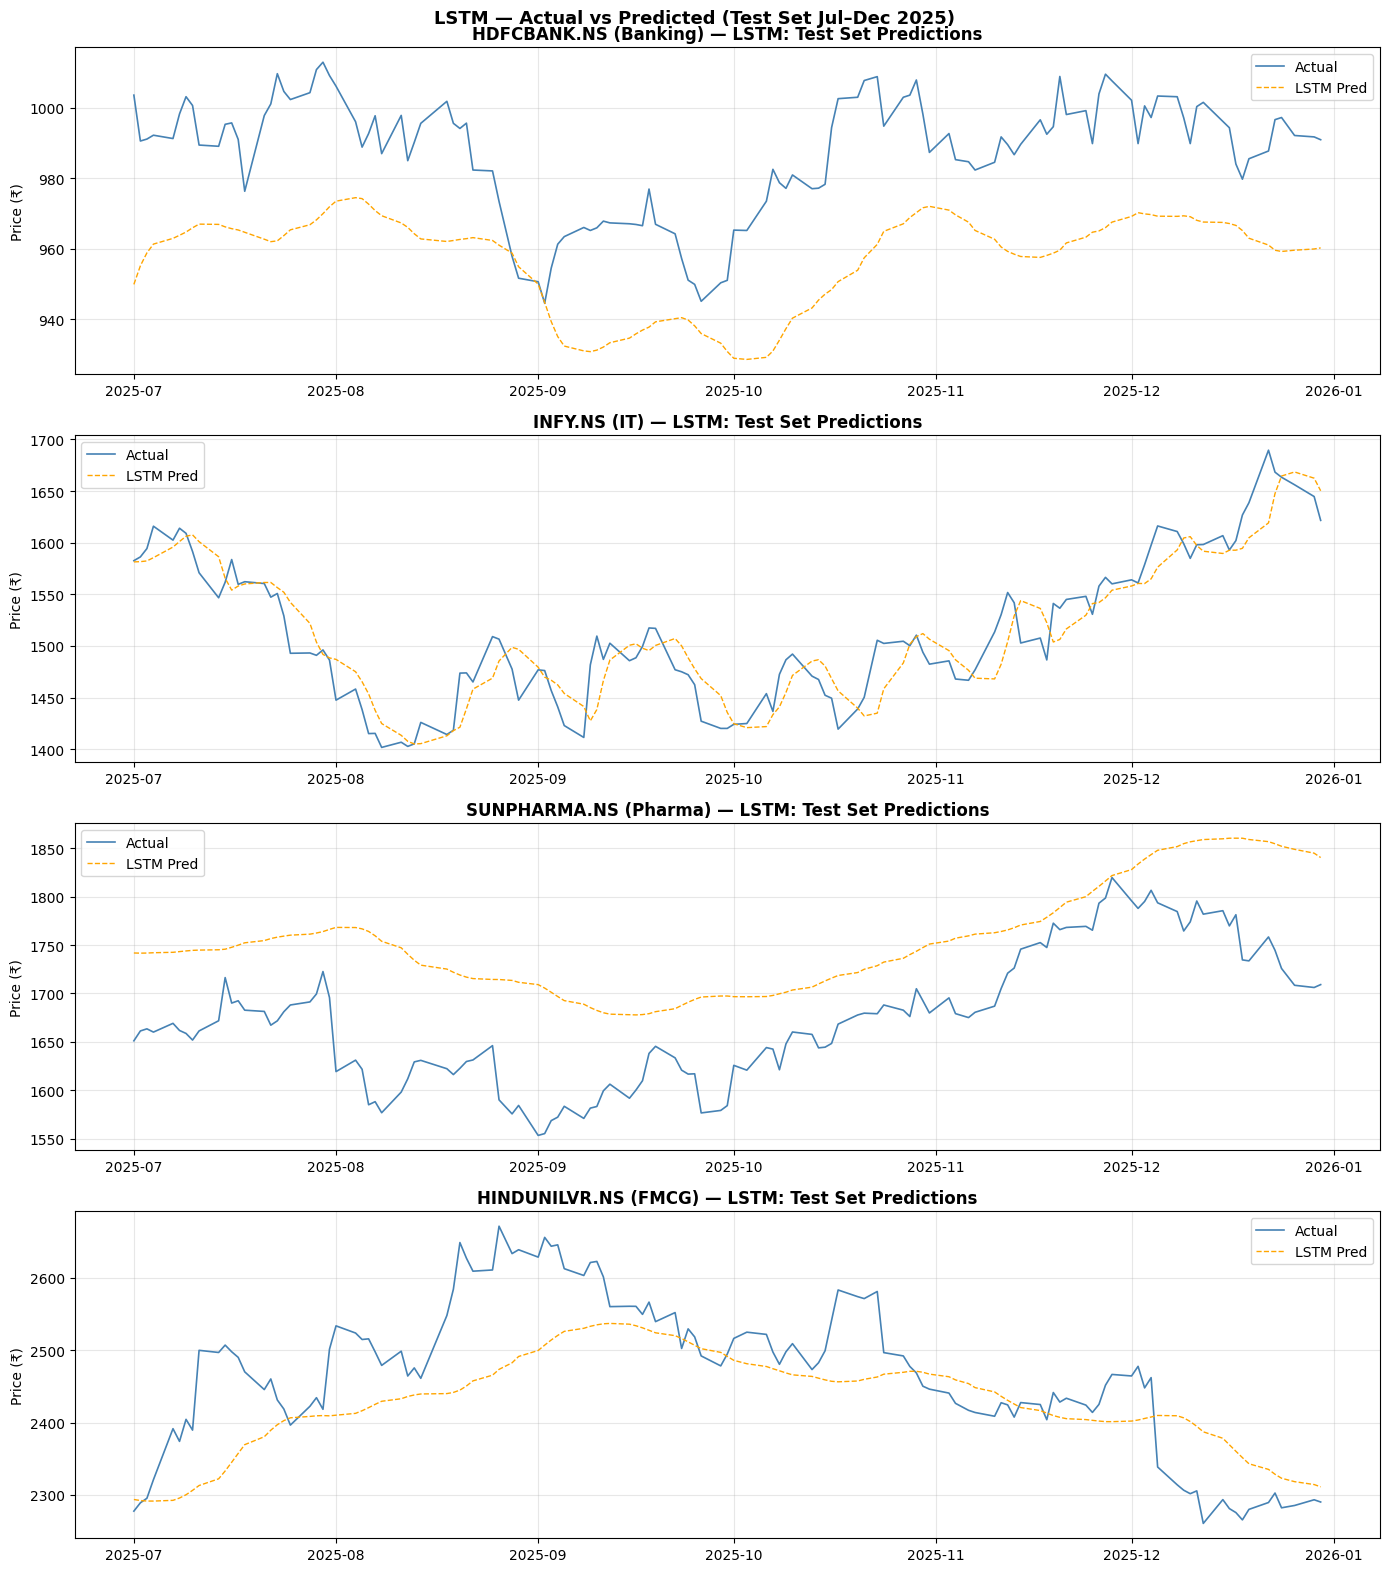

In [8]:
fig, axes = plt.subplots(len(TICKER_LIST), 1, figsize=(14, 4 * len(TICKER_LIST)), sharex=False)

for ax, ticker in zip(axes, TICKER_LIST):
    actual = test_close[ticker].dropna()
    preds  = lstm_test_preds[ticker]

    ax.plot(actual.index, actual.values, label='Actual',      linewidth=1.2, color='steelblue')
    ax.plot(actual.index, preds,         label='LSTM Pred', linewidth=1.0, color='orange', linestyle='--')
    ax.set_title(f'{ticker} ({SECTOR_MAP[ticker]}) — LSTM: Test Set Predictions', fontweight='bold')
    ax.set_ylabel('Price (₹)')
    ax.legend()

plt.suptitle('LSTM — Actual vs Predicted (Test Set Jul–Dec 2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/08_lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Metrics Summary Table (Task 6 input)

In [9]:
metrics_df = pd.DataFrame(lstm_metrics)
print('LSTM Evaluation Metrics — Test Set (Jul–Dec 2025)')
print('=' * 60)
print(metrics_df.to_string(index=False))

print(f'\nAverage MAPE    : {metrics_df["MAPE (%)"].mean():.2f}%')
print(f'Average RMSE    : {metrics_df["RMSE"].mean():.2f}')
print(f'Average Dir Acc : {metrics_df["Dir Acc (%)"].mean():.1f}%')

metrics_df.to_csv('../outputs/forecasts/lstm_metrics.csv', index=False)

LSTM Evaluation Metrics — Test Set (Jul–Dec 2025)
        Stock  Sector  MAPE (%)    RMSE  Dir Acc (%)
  HDFCBANK.NS Banking    3.0296 31.9192        47.58
      INFY.NS      IT    1.3656 26.0481        51.61
 SUNPHARMA.NS  Pharma    4.8076 87.6785        52.42
HINDUNILVR.NS    FMCG    2.5094 80.5023        47.58

Average MAPE    : 2.93%
Average RMSE    : 56.54
Average Dir Acc : 49.8%


---
## 8. Live 2-Day Forecast (Beyond Dec 2025)

In [11]:
full_close = pd.concat([train_close, test_close])

live_forecasts = []

for ticker in TICKER_LIST:
    print(f'Forecasting {ticker}...')
    scaler  = scalers[ticker]
    full_series = full_close[ticker].dropna()
    last_price  = full_series.iloc[-1]

    full_scaler = MinMaxScaler()
    full_scaled = full_scaler.fit_transform(full_series.values.reshape(-1, 1)).flatten()

    window = full_scaled[-LSTM_WINDOW:].reshape(1, LSTM_WINDOW, 1)

    current_input = list(full_scaled[-LSTM_WINDOW:])
    day_preds = []
    for _ in range(FORECAST_HORIZON):
        x = np.array(current_input[-LSTM_WINDOW:]).reshape(1, LSTM_WINDOW, 1)
        pred_scaled = lstm_models[ticker].predict(x, verbose=0)[0, 0]
        day_preds.append(pred_scaled)
        current_input.append(pred_scaled)

    day1_price = full_scaler.inverse_transform([[day_preds[0]]])[0, 0]
    day2_price = full_scaler.inverse_transform([[day_preds[1]]])[0, 0]

    live_forecasts.append({
        'Stock'             : ticker,
        'Sector'            : SECTOR_MAP[ticker],
        'Last Known Price'  : round(last_price, 2),
        'Forecast Day 1'    : round(day1_price, 2),
        'Forecast Day 2'    : round(day2_price, 2),
        'Pred Return D1 (%)': round((day1_price - last_price) / last_price * 100, 3),
        'Pred Return D2 (%)': round((day2_price - last_price) / last_price * 100, 3)
    })

live_df = pd.DataFrame(live_forecasts)
print('\nLive 2-Day Forecast:')
print(live_df.to_string(index=False))

Forecasting HDFCBANK.NS...
Forecasting INFY.NS...
Forecasting SUNPHARMA.NS...
Forecasting HINDUNILVR.NS...

Live 2-Day Forecast:
        Stock  Sector  Last Known Price  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS Banking             990.9          960.79          958.42              -3.039              -3.278
      INFY.NS      IT            1621.6         1632.18         1621.73               0.652               0.008
 SUNPHARMA.NS  Pharma            1709.1         1835.74         1834.30               7.410               7.326
HINDUNILVR.NS    FMCG            2290.2         2308.68         2307.10               0.807               0.738


In [12]:
live_df.to_csv('../outputs/forecasts/lstm_forecasts.csv', index=False)
print('\nSaved: outputs/forecasts/lstm_forecasts.csv')


Saved: outputs/forecasts/lstm_forecasts.csv


---
## 9. Summary

In [13]:
print('=' * 55)
print('NOTEBOOK 03 — LSTM SUMMARY')
print('=' * 55)

print('\nTest set performance:')
print(metrics_df[['Stock', 'MAPE (%)', 'RMSE', 'Dir Acc (%)']].to_string(index=False))

print('\nLive 2-day forecast:')
print(live_df[['Stock', 'Forecast Day 1', 'Forecast Day 2', 'Pred Return D1 (%)', 'Pred Return D2 (%)']].to_string(index=False))

print('\nFiles saved:')
print('  outputs/forecasts/lstm_forecasts.csv')
print('  outputs/forecasts/lstm_metrics.csv')
print('  outputs/plots/08_lstm_predictions.png')

NOTEBOOK 03 — LSTM SUMMARY

Test set performance:
        Stock  MAPE (%)    RMSE  Dir Acc (%)
  HDFCBANK.NS    3.0296 31.9192        47.58
      INFY.NS    1.3656 26.0481        51.61
 SUNPHARMA.NS    4.8076 87.6785        52.42
HINDUNILVR.NS    2.5094 80.5023        47.58

Live 2-day forecast:
        Stock  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS          960.79          958.42              -3.039              -3.278
      INFY.NS         1632.18         1621.73               0.652               0.008
 SUNPHARMA.NS         1835.74         1834.30               7.410               7.326
HINDUNILVR.NS         2308.68         2307.10               0.807               0.738

Files saved:
  outputs/forecasts/lstm_forecasts.csv
  outputs/forecasts/lstm_metrics.csv
  outputs/plots/08_lstm_predictions.png

